# Comparison Notebook: Simulasi Optimasi Task Scheduling

Notebook ini adalah fase simulasi program sebelum metode terpilih divalidasi pada VPS. Fokusnya adalah membandingkan beberapa kombinasi optimizer pada problem instance yang sama, lalu memilih kandidat terbaik untuk pengujian statistik CDF.

Alur eksperimen:

1. Menyiapkan seed, dataset, node, dan task.
2. Membentuk model sistem edge heterogen 3x3.
3. Menghitung baseline Round-Robin sebagai referensi objective.
4. Menjalankan single-run screening semua kandidat.
5. Menilai konvergensi, time-to-target, runtime, energy, dan latency.
6. Memilih top 3 dari screening.
7. Menjalankan CDF top 3 untuk melihat stabilitas hasil.

Metrik utama yang dibaca reviewer adalah final objective, time-to-target objective <= 0.75, runtime komputasi, serta trade-off energy dan latency.


## 1. Konfigurasi Global dan Reproducibility

Cell ini mengunci seed, ukuran grid, jumlah task, bobot objective, dan hyperparameter optimizer. Pemisahan seed dipakai agar sampling mesin, sampling task, dan proses optimizer tidak saling memengaruhi.


In [1]:
import sys
print(sys.executable)


/home/adinda-central/.venv/bin/python


In [39]:
# ============================================================
# SECTION 1 — GLOBAL CONFIG & RANDOM CONTROL
# ============================================================

import sys
from pathlib import Path

# VS Code kadang memilih /home/adinda-central/.venv saat workspace dibuka dari folder home.
# Bootstrap ini memastikan notebook tetap membaca dependency dari venv project.
PROJECT_ROOT = Path("/home/adinda-central/edge-computing-system")
PROJECT_SITE_PACKAGES = PROJECT_ROOT / ".venv" / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
if PROJECT_SITE_PACKAGES.exists() and str(PROJECT_SITE_PACKAGES) not in sys.path:
    sys.path.insert(0, str(PROJECT_SITE_PACKAGES))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import random
import os

# -------------------------------
# GLOBAL SEED CONTROL
# -------------------------------

GLOBAL_SEED = 2026

# Pisahkan seed supaya tidak saling ganggu
MACHINE_SEED   = 111
TASK_SEED      = 222
OPTIMIZER_SEED = 333

# Set global reproducibility
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

# Gunakan RNG object modern (lebih aman dari global state)
rng_machine   = np.random.default_rng(MACHINE_SEED)
rng_task      = np.random.default_rng(TASK_SEED)
rng_optimizer = np.random.default_rng(OPTIMIZER_SEED)

print("Seeds initialized.")
print(f"GLOBAL_SEED    : {GLOBAL_SEED}")
print(f"MACHINE_SEED   : {MACHINE_SEED}")
print(f"TASK_SEED      : {TASK_SEED}")
print(f"OPTIMIZER_SEED : {OPTIMIZER_SEED}")

# -------------------------------
# GRID
# -------------------------------

Nx, Ny = 3, 3
N_NODES = Nx * Ny
MAX_TASKS = 300

# -------------------------------
# OBJECTIVE WEIGHTS
# -------------------------------

alpha_cpu = 0.4
beta_mem  = 0.6

# Trade-off energy-latency
weight_energy  = 0.5
weight_latency = 0.5


# -------------------------------
# OPTIMIZER HYPERPARAMETERS
# -------------------------------

# PSO
PSO_SWARM_SIZE = 40
PSO_MAX_ITER   = 150
PSO_W          = 0.73
PSO_C1         = 1.6
PSO_C2         = 1.6

# DE
DE_POP_SIZE = 40
DE_MAX_ITER = 150
DE_F        = 0.6
DE_CR       = 0.85

# SA
SA_MAX_ITER   = 150
SA_INIT_TEMP  = 5.0
SA_COOLING    = 0.97

# TABU 
TABU_MAX_ITER = 300        
TABU_TENURE   = 30         
TABU_CANDIDATE_MOVES = 100 
TABU_STAGNATION_TRIGGER = 12 

print("\nGlobal configuration loaded.")


Seeds initialized.
GLOBAL_SEED    : 2026
MACHINE_SEED   : 111
TASK_SEED      : 222
OPTIMIZER_SEED : 333

Global configuration loaded.


## 2. Load Dataset

Cell ini langsung mengambil dataset dari workspace project, sehingga notebook bisa dijalankan manual tanpa bantuan script patch.

Dataset yang dipakai:

- `part-00000-of-00001.csv` untuk data mesin Google Cluster Trace.
- `spreadsheet_export.csv` untuk data task simulasi, karena file ini memiliki `cpu_req` dan `mem_req` yang diperlukan oleh model load, energy, dan latency.

Catatan: file lama `cpm_pso_input_part10_19_timeseries.csv` tidak dipakai di notebook ini karena tidak memiliki kolom `mem_req`. Jika dataset task tidak memiliki `latency_ms`, notebook membuat kolom kompatibilitas `latency_ms = 0.0`; latency simulasi tetap dihitung dari service time, queue delay model, dan pressure memory pada `system_model.py`.


In [40]:
# ============================================================
# SECTION 2 - LOAD MACHINE & CLEAN TASK DATASET
# ============================================================

from pathlib import Path
import pandas as pd

# Notebook ini diasumsikan dijalankan dari root project:
# /home/adinda-central/edge-computing-system
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "part-00000-of-00001.csv").exists():
    PROJECT_ROOT = Path("/home/adinda-central/edge-computing-system")

# -------------------------------
# MACHINE DATA LOAD
# -------------------------------
machine_path = PROJECT_ROOT / "part-00000-of-00001.csv"

machine_df = pd.read_csv(machine_path, header=None)
machine_df.columns = [
    "time",
    "machine_id",
    "event_type",
    "platform_id",
    "cpu_capacity",
    "memory_capacity",
]

print("Machine data loaded from:", machine_path)
print("Total raw machine rows:", len(machine_df))
display(machine_df.head())
display(machine_df.describe())

# -------------------------------
# TASK DATA LOAD
# -------------------------------
# Dipilih karena memiliki cpu_req dan mem_req untuk objective simulasi.
task_path = PROJECT_ROOT / "spreadsheet_export.csv"

task_df = pd.read_csv(task_path)

required_task_columns = {"job_id", "task_index", "cpu_req", "mem_req"}
missing_task_columns = required_task_columns - set(task_df.columns)
if missing_task_columns:
    raise ValueError(
        "Task dataset tidak memiliki kolom wajib: "
        f"{sorted(missing_task_columns)}. "
        "Gunakan dataset yang memiliki cpu_req dan mem_req."
    )

# Kompatibilitas dengan cell baseline lama. Model latency simulasi tidak
# bergantung pada latency_ms dataset; latency dihitung di system_model.py.
if "latency_ms" not in task_df.columns:
    task_df["latency_ms"] = 0.0

print("\nTask dataset loaded from:", task_path)
print("Total cleaned tasks:", len(task_df))
print("Task columns:", list(task_df.columns))
display(task_df.head())
display(task_df.describe())


Machine data loaded from: /home/adinda-central/edge-computing-system/part-00000-of-00001.csv
Total raw machine rows: 37780


,time,machine_id,event_type,platform_id,cpu_capacity,memory_capacity
0,0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
1,0,6,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
2,0,7,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
3,0,10,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
4,0,13,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493


,time,machine_id,event_type,cpu_capacity,memory_capacity
count,3.778000e+04,3.778000e+04,37780.000000,37748.000000,37748.000000
mean,8.717087e+11,1.375694e+09,0.627766,0.526068,0.476737
std,8.504981e+11,1.740160e+09,0.790174,0.122016,0.193163
min,0.000000e+00,5.000000e+00,0.000000,0.250000,0.030850
25%,0.000000e+00,1.297762e+07,0.000000,0.500000,0.249300
50%,7.220264e+11,3.516270e+08,0.000000,0.500000,0.499500
75%,1.619919e+12,2.610162e+09,1.000000,0.500000,0.499500
max,2.506135e+12,6.457071e+09,2.000000,1.000000,1.000000



Task dataset loaded from: /home/adinda-central/edge-computing-system/spreadsheet_export.csv
Total cleaned tasks: 504567
Task columns: ['job_id', 'task_index', 'queue_delay', 'service_time', 'cpu_req', 'mem_req', 'priority', 'latency_ms']


,job_id,task_index,queue_delay,service_time,cpu_req,mem_req,priority,latency_ms
0,17109330,60,35.407070,NaN,0.06250,0.01398,9,0.0
1,17109330,88,2.256250,NaN,0.06250,0.01398,9,0.0
2,28185708,9,4.547237,NaN,0.01562,0.00795,1,0.0
3,28185708,0,2.885578,NaN,0.01562,0.00795,1,0.0
4,28185708,1,1.618932,NaN,0.01562,0.00795,1,0.0


,job_id,task_index,queue_delay,service_time,cpu_req,mem_req,priority,latency_ms
count,5.045670e+05,504567.000000,504567.000000,291662.000000,504567.000000,504567.000000,504567.000000,504567.0
mean,6.238229e+09,920.548078,-25.279486,-4.415813,0.037265,0.026823,2.696147,0.0
std,1.728092e+08,2284.372799,460.947570,1068.294950,0.029530,0.022872,2.026682,0.0
min,1.710933e+07,0.000000,-5009.186567,-4982.438931,0.000000,0.000000,0.000000,0.0
25%,6.255710e+09,75.000000,2.569844,-36.278552,0.012500,0.011120,0.000000,0.0
50%,6.257058e+09,324.000000,6.421877,157.570054,0.024990,0.025450,4.000000,0.0
75%,6.258457e+09,820.000000,34.033008,379.740961,0.062500,0.031800,4.000000,0.0
max,6.260717e+09,20008.000000,4636.376431,4631.917495,0.437500,0.636700,11.000000,0.0


## 3. Konfigurasi Node Heterogen

Sistem simulasi memakai 9 edge node pada grid 3x3. Kapasitas CPU dan memory dibuat heterogen agar optimizer diuji pada kondisi edge yang tidak seragam.


In [41]:
# ============================================================
# SECTION 3 — BUILD MACHINE CONFIGURATION (COMPATIBLE MODE)
# ============================================================

# -------------------------------
# FILTER MACHINE ADD EVENTS
# -------------------------------

machine_active = machine_df[machine_df["event_type"] == 0].copy()
machine_active = machine_active.drop_duplicates(subset=["machine_id"])
machine_active = machine_active.reset_index(drop=True)

print("Total available machines:", len(machine_active))

machine_subset = machine_active.sample(
    n=N_NODES,
    random_state=MACHINE_SEED
).reset_index(drop=True)

mem_capacity_nodes = machine_subset["memory_capacity"].values

# ======================
# NODE HETEROGENEITY (FROZEN)
# ======================

# MEMORY: raw-based heterogeneity
hetero_factor_mem = rng_machine.uniform(0.5, 1.5, size=N_NODES)
mem_capacity_scaled = mem_capacity_nodes * hetero_factor_mem

# CPU: fully synthetic (as in your latest version)
cpu_capacity_scaled = rng_machine.uniform(0.8, 1.5, size=N_NODES)

# Save final arrays
cpu_caps = cpu_capacity_scaled
mem_caps = mem_capacity_scaled

print("\nMachine configuration frozen.")
print("Simulation nodes:", N_NODES)

print("\n===== FULL NODE CONFIGURATION =====")
print(f"{'Node':<6} {'CPU_CAP':<15} {'MEM_CAP':<15}")

for i in range(N_NODES):
    print(f"{i:<6} {cpu_caps[i]:<15.6f} {mem_caps[i]:<15.6f}")

print("====================================")



Total available machines: 12583

Machine configuration frozen.
Simulation nodes: 9

===== FULL NODE CONFIGURATION =====
Node   CPU_CAP         MEM_CAP        
0      0.938260        0.162958       
1      1.036793        0.166857       
2      1.300792        0.502479       
3      0.855310        0.578480       
4      1.091207        0.633157       
5      1.078421        0.304309       
6      1.457196        0.323491       
7      1.013797        0.733639       
8      1.226275        0.186214       


## 4. Sampling Task dan Pembentukan Array Sistem

Dari dataset task, notebook mengambil 300 task sebagai satu problem instance. Setiap task memiliki demand CPU dan memory yang menjadi dasar evaluasi assignment.


In [42]:
# ============================================================
# SECTION 4 — TASK SAMPLING (FROZEN INSTANCE)
# ============================================================

# -------------------------------
# TASK SAMPLING
# -------------------------------

if MAX_TASKS is not None and MAX_TASKS < len(task_df):
    task_sampled = task_df.sample(
        n=MAX_TASKS,
        random_state=TASK_SEED
    ).reset_index(drop=True)
else:
    task_sampled = task_df.copy().reset_index(drop=True)

print("Total tasks used:", len(task_sampled))

# -------------------------------
# BUILD SYSTEM ARRAYS
# -------------------------------

cpu_demands = task_sampled["cpu_req"].values
mem_demands = task_sampled["mem_req"].values

N_tasks = len(cpu_demands)

print("\nSystem task arrays built.")
print("N_tasks:", N_tasks)

# -------------------------------
# DISPLAY FIRST 10 TASKS (TABLE)
# -------------------------------

task_preview_full = task_sampled[[
    "job_id",
    "task_index",
    "cpu_req",
    "mem_req"
]].head(10)

print("\n===== FIRST 10 TASKS =====")
display(task_preview_full.head(10))



Total tasks used: 300

System task arrays built.
N_tasks: 300

===== FIRST 10 TASKS =====


,job_id,task_index,cpu_req,mem_req
0,6259567948,1759,0.062500,0.031800
1,6259311320,452,0.062500,0.031800
2,6260520411,1737,0.009064,0.047730
3,6255532702,600,0.068730,0.011930
4,5633031188,614,0.037480,0.016050
5,6254984728,1183,0.062500,0.122800
6,6258266572,241,0.024990,0.025450
7,6258344025,1622,0.024990,0.079590
8,6256895398,3,0.012500,0.006187
9,6255435217,83,0.006248,0.038640


## 5. System Model dan Objective Function

Cell ini menulis `system_model.py` yang berisi model load, energy, latency, objective function, dan greedy refinement helper. Objective dinormalisasi terhadap baseline sehingga Round-Robin bernilai 1.0.


In [43]:
%%writefile system_model.py

import numpy as np


# ============================================================
# SYSTEM MODEL
# ============================================================


# ------------------------------------------------------------
# COMPUTE LOAD
# ------------------------------------------------------------

class SystemModel:

    def compute_computing_load(self, assignments):
        return compute_computing_load(
            assignments,
            self.cpu_demands,
            self.mem_demands,
            self.cpu_caps,
            self.mem_caps,
            self.alpha_cpu,
            self.beta_mem
        )

def compute_computing_load(assignments,
                           cpu_demands,
                           mem_demands,
                           cpu_caps,
                           mem_caps,
                           alpha_cpu,
                           beta_mem):

    N_nodes = len(cpu_caps)

    cpu_used = np.zeros(N_nodes)
    mem_used = np.zeros(N_nodes)

    for t, node in enumerate(assignments):
        cpu_used[node] += cpu_demands[t]
        mem_used[node] += mem_demands[t]

    cpu_util = cpu_used / cpu_caps
    mem_util = mem_used / mem_caps

    load = alpha_cpu * cpu_util + beta_mem * mem_util

    return load, cpu_util, mem_util


# ------------------------------------------------------------
# ENERGY MODEL (SOFT PENALTY)
# ------------------------------------------------------------
def energy_of_configuration(assignments,
                            cpu_demands,
                            mem_demands,
                            cpu_caps,
                            mem_caps):

    N_nodes = len(cpu_caps)

    cpu_used = np.zeros(N_nodes)
    mem_used = np.zeros(N_nodes)

    for t, node in enumerate(assignments):
        cpu_used[node] += cpu_demands[t]
        mem_used[node] += mem_demands[t]

    cpu_util = cpu_used / cpu_caps
    mem_util = mem_used / mem_caps

    # Power parameters
    P_idle = 10
    P_cpu_dyn = 12
    P_mem_dyn = 5
    P_sleep = 2
    delta_t = 1

    energy_nodes = np.zeros(N_nodes)

    for i in range(N_nodes):

        if cpu_util[i] > 0.01:
            power = (
                P_idle
                + P_cpu_dyn * min(cpu_util[i], 1.0)
                + P_mem_dyn * min(mem_util[i], 1.0)
            )
        else:
            power = P_sleep

        # Soft CPU stress penalty
        if cpu_util[i] <= 0.8:
            overload_penalty = 0
        elif cpu_util[i] <= 1.0:
            overload_penalty = 15 * (cpu_util[i] - 0.8)
        else:
            overload_penalty = 15 * 0.2 + 40 * (cpu_util[i] - 1.0)

        energy_nodes[i] = power * delta_t + overload_penalty

    # Soft consolidation penalty
    active_nodes = np.sum(cpu_util > 0.05)
    active_penalty = 3 * active_nodes

    total_energy = np.sum(energy_nodes) + active_penalty

    return float(total_energy)


# ------------------------------------------------------------
# LATENCY MODEL (SOFT CONGESTION)
# ------------------------------------------------------------
def latency_of_configuration(assignments,
                             cpu_demands,
                             mem_demands,
                             latency_ms,
                             cpu_caps,
                             mem_caps):

    N_nodes = len(cpu_caps)

    cpu_used = np.zeros(N_nodes)
    mem_used = np.zeros(N_nodes)

    for t, node in enumerate(assignments):
        cpu_used[node] += cpu_demands[t]
        mem_used[node] += mem_demands[t]

    cpu_util = cpu_used / cpu_caps
    mem_util = mem_used / mem_caps

    latencies = np.zeros(len(assignments))

    for t, node in enumerate(assignments):

        service_time = cpu_demands[t] / cpu_caps[node]

        rho = min(cpu_util[node], 0.95)
        queue_delay = service_time * rho / (1 - rho + 0.05)

        mem_over = max(0.0, mem_util[node] - 1.0)
        mem_penalty = 2.0 * (mem_over ** 2)

        latencies[t] = service_time + queue_delay + mem_penalty

    mean_latency = np.mean(latencies)

    return float(mean_latency), latencies


# ------------------------------------------------------------
# OBJECTIVE FUNCTION (IDENTICAL STRUCTURE)
# ------------------------------------------------------------
def objective_value(assignments,
                    cpu_demands,
                    mem_demands,
                    latency_ms,
                    cpu_caps,
                    mem_caps,
                    E_ref,
                    L_ref,
                    weight_energy,
                    weight_latency):

    E = energy_of_configuration(
        assignments,
        cpu_demands,
        mem_demands,
        cpu_caps,
        mem_caps
    )

    L, _ = latency_of_configuration(
        assignments,
        cpu_demands,
        mem_demands,
        latency_ms,
        cpu_caps,
        mem_caps
    )

    cost = (
        weight_energy * (E / E_ref) +
        weight_latency * (L / L_ref)
    )

    return cost, E, L

# ------------------------------------------------------------
# GREEDY REFINEMENT (SEARCH IMPROVEMENT OPERATOR)
# ------------------------------------------------------------
def greedy_refinement(assignments,
                      cpu_demands,
                      mem_demands,
                      latency_ms,
                      cpu_caps,
                      mem_caps,
                      E_ref,
                      L_ref,
                      weight_energy,
                      weight_latency,
                      rng,
                      steps=20):

    best_assign = assignments.copy()

    best_cost, _, _ = objective_value(
        best_assign,
        cpu_demands,
        mem_demands,
        latency_ms,
        cpu_caps,
        mem_caps,
        E_ref,
        L_ref,
        weight_energy,
        weight_latency
    )

    N_nodes = len(cpu_caps)

    for _ in range(steps):

        # random pilih 1 task
        t = rng.integers(0, len(best_assign))
        current_node = best_assign[t]

        for node in range(N_nodes):

            if node == current_node:
                continue

            trial = best_assign.copy()
            trial[t] = node

            trial_cost, _, _ = objective_value(
                trial,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_ref,
                L_ref,
                weight_energy,
                weight_latency
            )

            # first improvement
            if trial_cost < best_cost:
                best_cost = trial_cost
                best_assign = trial
                break

    return best_assign, best_cost

Overwriting system_model.py


## 6. Baseline Round-Robin

Round-Robin digunakan sebagai baseline simulasi. Nilai `E_REF` dan `L_REF` dari baseline ini menjadi referensi normalisasi objective function.


In [44]:
from system_model import (
    energy_of_configuration,
    latency_of_configuration,
    objective_value
)

# ============================================================
# SECTION 6 — BASELINE FREEZE
# ============================================================

# -------------------------------
# BASELINE ASSIGNMENT (ROUND-ROBIN)
# -------------------------------

baseline_assignment = np.arange(N_tasks) % N_NODES

print("Baseline assignment created.")
print("First 15 assignments:", baseline_assignment[:15])


# -------------------------------
# COMPUTE BASELINE METRICS
# -------------------------------

# Define latency_ms from task_sampled if it hasn't been defined yet
if 'latency_ms' not in globals():
    latency_ms = task_sampled["latency_ms"].values

E_REF = energy_of_configuration(
    baseline_assignment,
    cpu_demands,
    mem_demands,
    cpu_caps,
    mem_caps
)

L_REF, _ = latency_of_configuration(
    baseline_assignment,
    cpu_demands,
    mem_demands,
    latency_ms, # Added missing argument
    cpu_caps,
    mem_caps
)

print("\n===== BASELINE METRICS =====")
print(f"E_REF: {E_REF:.6f}")
print(f"L_REF: {L_REF:.6f}")


# -------------------------------
# BASELINE OBJECTIVE VALUE
# -------------------------------

baseline_cost, E_check, L_check = objective_value(
    baseline_assignment,
    cpu_demands,
    mem_demands,
    latency_ms,
    cpu_caps,
    mem_caps,
    E_REF,
    L_REF,
    weight_energy,
    weight_latency
)

print("\n===== BASELINE OBJECTIVE =====")
print(f"Baseline cost (should be \u2248 1.0): {baseline_cost:.6f}")
print(f"Energy check: {E_check:.6f}")
print(f"Latency check: {L_check:.6f}")

Baseline assignment created.
First 15 assignments: [0 1 2 3 4 5 6 7 8 0 1 2 3 4 5]

===== BASELINE METRICS =====
E_REF: 332.408428
L_REF: 12.975185

===== BASELINE OBJECTIVE =====
Baseline cost (should be ≈ 1.0): 1.000000
Energy check: 332.408428
Latency check: 12.975185


## 7. Evaluation Wrapper

Wrapper ini menyatukan cara evaluasi semua optimizer. Dengan wrapper yang sama, setiap model dinilai memakai objective function, energy model, dan latency model yang identik.


In [45]:
# ============================================================
# SECTION 7 — UNIFIED EVALUATION WRAPPER
# ============================================================

from system_model import (
    objective_value,
    greedy_refinement
)

def evaluate_solution(assignments,
                      cpu_demands,
                      mem_demands,
                      latency_ms,
                      cpu_caps,
                      mem_caps,
                      E_REF,
                      L_REF,
                      weight_energy,
                      weight_latency,
                      use_greedy=False,
                      greedy_steps=10,
                      rng=None):
    """
    Unified evaluation pipeline for all optimizers.
    """

    candidate = assignments.copy()

    # --- Optional greedy refinement ---
    if use_greedy:
        if rng is None:
            raise ValueError("RNG must be provided if use_greedy=True")

        candidate, _ = greedy_refinement(
            candidate,
            cpu_demands,
            mem_demands,
            latency_ms,
            cpu_caps,
            mem_caps,
            E_REF,
            L_REF,
            weight_energy,
            weight_latency,
            rng,
            steps=greedy_steps
        )

    cost, energy, latency = objective_value(
        candidate,
        cpu_demands,
        mem_demands,
        latency_ms,
        cpu_caps,
        mem_caps,
        E_REF,
        L_REF,
        weight_energy,
        weight_latency
    )

    return candidate, cost, energy, latency


## 8. Timing Utilities

Bagian ini menyediakan fungsi pengukuran runtime, time-to-target, dan history waktu agar konvergensi antar optimizer dapat dibandingkan secara fair.


In [46]:
# ============================================================
# SECTION X — TIMING UTILITIES
# ============================================================

import time
import numpy as np

TIMING_BUFFER = []

def timing_start():
    return time.perf_counter()

def time_to_target(history, runtime, threshold=0.75):

    objs = history["obj"]

    if len(objs) == 0:
        return None

    if "time" not in history or len(history["time"]) != len(objs):
        times = np.linspace(0, runtime, len(objs))
    else:
        times = history["time"]

    for i in range(1, len(objs)):   # skip index 0
        if objs[i] <= threshold:
            return times[i]

    return None

def ensure_time_history(history, runtime):
    """
    Jika optimizer tidak mencatat waktu internal,
    buat estimasi waktu kumulatif berdasarkan runtime total.
    """
    if "time" not in history or len(history["time"]) == 0:
        n = len(history["obj"])
        history["time"] = np.linspace(0, runtime, n)

def objective_at_time(history, t_target=10):

    times = np.array(history["time"])
    objs = np.array(history["obj"])

    if len(times) == 0:
        return None

    idx = np.where(times <= t_target)[0]

    if len(idx) == 0:
        return objs[0]

    return objs[idx[-1]]

## Local Balancing / Refinement Methods

Setelah global optimizer membuat assignment awal, local method dapat dipakai untuk memperbaiki solusi secara lokal.

**Diffusion Local Refinement**

Diffusion melakukan migrasi task berbasis tetangga grid. Untuk setiap task, metode ini mengevaluasi kandidat perpindahan ke node tetangga menggunakan objective global energy-latency, lalu memindahkan task hanya jika perpindahan tersebut benar-benar memperbaiki objective.

Parameter tuning yang dipakai pada notebook ini:

```text
gamma = 0.08
max_steps = 1
objective_epsilon = 1e-9
trigger Tabu = hanya saat no_improve_counter >= TABU_STAGNATION_TRIGGER
```

**CPM**

CPM mempertahankan state grid 2D untuk merepresentasikan kondisi node, lalu memakai metropolis sampling untuk memperbarui state. Dalam notebook ini CPM dipakai sebagai pembanding local method berbasis grid.

**None**

Tidak memakai local refinement. Varian ini penting sebagai ablation, khususnya `TABU+NONE` vs `TABU+DIFFUSION`, agar kontribusi Diffusion dapat dilihat secara langsung.


In [47]:
class CPMOptimizer:

    def __init__(self, nx, ny):
        self.nx = nx
        self.ny = ny
        self.N = nx * ny
        self.state = np.zeros(self.N, dtype=int)
        self.lambda_pen = 1.0

    def refine(self, assignments, system_model):

        # reset state tiap refine
        self.state[:] = 0

        for _ in range(10):

            load, cpu_util, _ = system_model.compute_computing_load(assignments)

            self.metropolis_step(cpu_util, 5.0, rng_optimizer)

        return assignments, self.state

    def neighbors(self, i):
        x, y = node_coordinates(i)
        nbs = []
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx_, ny_ = x + dx, y + dy
            if 0 <= nx_ < self.nx and 0 <= ny_ < self.ny:
                nbs.append(nx_ * self.ny + ny_)
        return nbs

    def local_energy(self, i, util):
        si = self.state[i]
        e = 0.0
        for nb in self.neighbors(i):
            e += abs(si - self.state[nb])
        overload = max(0.0, util[i] - 0.8)
        return e + self.lambda_pen * overload * 10.0

    def metropolis_step(self, util, T, rng):

        i = rng.integers(0, self.N)

        s_old = self.state[i]

        s_new = rng.choice([0,1,2])

        E_old = self.local_energy(i, util)

        self.state[i] = s_new

        E_new = self.local_energy(i, util)

        if E_new > E_old:

            prob = np.exp(-(E_new-E_old)/max(T,1e-6))

            if rng.random() > prob:
                self.state[i] = s_old

def map_position_to_assignment(pos_vector):
    return np.round(pos_vector).astype(int) % N_NODES

def node_coordinates(node_index):
    return (node_index // Ny, node_index % Ny)

In [48]:
# ====================== DIFFUSION LOCAL OPTIMIZER ======================
class DiffusionLocalOptimizer:

    def __init__(self, adjacency, gamma=0.08, max_steps=1, objective_epsilon=1e-9, node_powers=None, idle_powers=None, max_powers=None, latency_ms=None, energy_weight=0.68):
        self.adjacency = adjacency
        self.gamma = gamma
        self.max_steps = max_steps
        self.objective_epsilon = objective_epsilon
        self.node_powers = node_powers
        self.idle_powers = idle_powers
        self.max_powers = max_powers
        self.latency_ms = latency_ms
        self.energy_weight = energy_weight

    def _local_cost(self, task_idx, node_idx, cpu_demands, cpu_caps, cpu_util, mem_demands=None, mem_caps=None, mem_util=None):
        cpu_demand = float(cpu_demands[task_idx])
        cpu_cap = float(cpu_caps[node_idx])
        cpu_ratio = min(cpu_demand / max(cpu_cap, 1e-6), 1.0)
        service_time = cpu_demand / max(cpu_cap, 1e-6)

        current_cpu_util = float(cpu_util[node_idx])
        projected_cpu_util = current_cpu_util + (cpu_demand / max(cpu_cap, 1e-6))
        queue_penalty = service_time * max(0.0, projected_cpu_util - 0.8) * 1.35

        mem_penalty = 0.0
        mem_ratio = 0.0
        if mem_demands is not None and mem_caps is not None and mem_util is not None:
            mem_demand = float(mem_demands[task_idx])
            mem_cap = float(mem_caps[node_idx])
            mem_ratio = min(mem_demand / max(mem_cap, 1e-6), 1.0)
            projected_mem_util = float(mem_util[node_idx]) + (mem_demand / max(mem_cap, 1e-6))
            mem_penalty = max(0.0, projected_mem_util - 1.0) ** 2

        latency = service_time + queue_penalty + mem_penalty
        if self.latency_ms is not None:
            latency += float(self.latency_ms[node_idx])

        if self.idle_powers is not None and self.max_powers is not None:
            effective_util = min(0.8 * cpu_ratio + 0.2 * mem_ratio, 1.0)
            power_w = float(self.idle_powers[node_idx]) + (
                float(self.max_powers[node_idx]) - float(self.idle_powers[node_idx])
            ) * effective_util
            energy = power_w * service_time
        elif self.node_powers is not None:
            energy = float(self.node_powers[node_idx]) * projected_cpu_util
        else:
            energy = projected_cpu_util

        return self.energy_weight * energy + (1.0 - self.energy_weight) * latency

    def refine(self, assignments, system_model):
        best_assign = assignments.copy()
        n_nodes = len(cpu_caps)
        n_tasks = len(cpu_demands)

        for _ in range(self.max_steps):
            current_global_cost, _, _ = objective_value(
                best_assign,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_REF,
                L_REF,
                weight_energy,
                weight_latency,
            )
            accepted_any = False

            for t in range(n_tasks):
                cpu_used = np.zeros(n_nodes)
                mem_used = np.zeros(n_nodes)

                for idx, node in enumerate(best_assign):
                    cpu_used[node] += cpu_demands[idx]
                    mem_used[node] += mem_demands[idx]

                cpu_util = cpu_used / cpu_caps
                mem_util = mem_used / np.maximum(mem_caps, 1e-6)

                current_node = best_assign[t]
                neighbors = self.adjacency[current_node]

                best_neighbor = current_node
                best_neighbor_cost = current_global_cost

                for neighbor in neighbors:
                    projected_neighbor = cpu_util[neighbor] + cpu_demands[t] / cpu_caps[neighbor]
                    if projected_neighbor > 1.2:
                        continue

                    projected_mem_neighbor = mem_util[neighbor] + mem_demands[t] / max(mem_caps[neighbor], 1e-6)
                    if projected_mem_neighbor > 1.2:
                        continue

                    trial_assign = best_assign.copy()
                    trial_assign[t] = neighbor
                    trial_cost, _, _ = objective_value(
                        trial_assign,
                        cpu_demands,
                        mem_demands,
                        latency_ms,
                        cpu_caps,
                        mem_caps,
                        E_REF,
                        L_REF,
                        weight_energy,
                        weight_latency,
                    )

                    if trial_cost + self.objective_epsilon < best_neighbor_cost:
                        best_neighbor_cost = trial_cost
                        best_neighbor = neighbor

                if best_neighbor != current_node:
                    best_assign[t] = best_neighbor
                    current_global_cost = best_neighbor_cost
                    accepted_any = True

            if not accepted_any:
                break

        return best_assign

In [49]:
def build_local_optimizer(name, topology):

    if name == "cpm":
        return CPMOptimizer(
            nx=Nx,
            ny=Ny
        )

    elif name == "diffusion":
        return DiffusionLocalOptimizer(
            adjacency=adjacency,
            gamma=0.08,
            max_steps=1,
            latency_ms=latency_ms,
            energy_weight=weight_energy
        )

    elif name == "none":
        return None


## Global Optimizers

Notebook membandingkan tiga keluarga global optimizer: BFO, Tabu Search, dan PSO. Semua optimizer mengevaluasi solusi dengan objective function yang sama sehingga hasil screening dapat dibandingkan secara fair.


### BFO, Tabu Search, dan PSO

**BFO (Bacterial Foraging Optimization)** menggunakan mekanisme chemotaxis, reproduction, dan elimination-dispersal. Setiap bakteri merepresentasikan assignment vector task ke node.

**Tabu Search** adalah optimizer utama yang diuji untuk kandidat hybrid. Move yang digunakan mencakup single task reassignment dan swap antar task. Tabu list mencegah cycling, aspiration mengizinkan move tabu jika menghasilkan solusi global terbaik, dan diversification dilakukan saat pencarian stagnan.

Parameter Tabu yang dipakai setelah tuning:

```text
TABU_MAX_ITER = 300
TABU_TENURE = 30
TABU_CANDIDATE_MOVES = 100
TABU_STAGNATION_TRIGGER = 12
```

**PSO (Particle Swarm Optimization)** merepresentasikan setiap partikel sebagai vektor posisi kontinu yang dipetakan ke assignment node diskret.

Semua optimizer memakai seed, dataset, jumlah task, node, baseline, dan objective function yang sama.


In [50]:
# ====================== BFO ======================
import time # Added import for time.perf_counter()

def hybrid_bfo(system_model_instance,
               local_optimizer=None,
               timing_callback=None,
               timing_end=None): # Note: the passed timing_end will not be used in the inner loop as its behavior is not compatible with elimination_cycle_times

    N_tasks = len(cpu_demands)
    N_bacteria = 40
    Nc = 12 # Number of chemotactic steps
    Nre = 6 # Number of reproduction steps
    Ned = 6 # Number of elimination-dispersal events
    Ped = 0.2 # Probability of elimination-dispersal

    # ======================
    # INITIAL POPULATION
    # Each bacterium is an assignment array
    # ======================
    population = [
        rng_optimizer.integers(0, N_NODES, size=N_tasks)
        for _ in range(N_bacteria)
    ]

    # Initialize gbest_assign with baseline_assignment to ensure it's never None
    gbest_assign = baseline_assignment.copy()
    _, gbest_val, _, _ = evaluate_solution(
        gbest_assign,
        cpu_demands,
        mem_demands,
        latency_ms,
        cpu_caps,
        mem_caps,
        E_REF,
        L_REF,
        weight_energy,
        weight_latency
    )

    history_bfo = {"obj": [], "energy": [], "latency": [], "time": []}

    start_time = time.perf_counter()

    for l in range(Ned):

        for k in range(Nre): # Reproduction Loop

            bacterium_costs = np.zeros(N_bacteria)

            # ======================
            # CHEMOTAXIS
            # ======================
            for j in range(Nc):   # chemotaxis iteration

                for i in range(N_bacteria):

                    current_assign_bacterium = population[i].copy()

                    _, current_cost_bacterium, _, _ = evaluate_solution(
                        current_assign_bacterium,
                        cpu_demands,
                        mem_demands,
                        latency_ms,
                        cpu_caps,
                        mem_caps,
                        E_REF,
                        L_REF,
                        weight_energy,
                        weight_latency
                    )

                    best_bacterium_cost_in_chemo = current_cost_bacterium
                    best_bacterium_assign_in_chemo = current_assign_bacterium.copy()

                    # --- TUMBLE ---
                    t = rng_optimizer.integers(0, N_tasks)
                    new_node = rng_optimizer.integers(0, N_NODES)

                    trial_assign_bacterium = best_bacterium_assign_in_chemo.copy()
                    trial_assign_bacterium[t] = new_node

                    _, cost_trial_bacterium, _, _ = evaluate_solution(
                        trial_assign_bacterium,
                        cpu_demands,
                        mem_demands,
                        latency_ms,
                        cpu_caps,
                        mem_caps,
                        E_REF,
                        L_REF,
                        weight_energy,
                        weight_latency
                    )

                    # --- SWIM ---
                    if cost_trial_bacterium < best_bacterium_cost_in_chemo:
                        best_bacterium_cost_in_chemo = cost_trial_bacterium
                        best_bacterium_assign_in_chemo = trial_assign_bacterium.copy()

                    population[i] = best_bacterium_assign_in_chemo
                    bacterium_costs[i] = best_bacterium_cost_in_chemo

                    # update global best
                    if best_bacterium_cost_in_chemo < gbest_val:
                        gbest_val = best_bacterium_cost_in_chemo
                        gbest_assign = best_bacterium_assign_in_chemo.copy()

                # ======================
                # CHEMOTAXIS LOGGING
                # ======================
                _, cost, E, L = evaluate_solution(
                    gbest_assign,
                    cpu_demands,
                    mem_demands,
                    latency_ms,
                    cpu_caps,
                    mem_caps,
                    E_REF,
                    L_REF,
                    weight_energy,
                    weight_latency
                )

                history_bfo["obj"].append(cost)
                history_bfo["energy"].append(E)
                history_bfo["latency"].append(L)
                history_bfo["time"].append(time.perf_counter() - start_time)

                population[i] = best_bacterium_assign_in_chemo
                bacterium_costs[i] = best_bacterium_cost_in_chemo

                if best_bacterium_cost_in_chemo < gbest_val:
                    gbest_val = best_bacterium_cost_in_chemo
                    gbest_assign = best_bacterium_assign_in_chemo.copy()

                    _, cost, E, L = evaluate_solution(
                        gbest_assign,
                        cpu_demands,
                        mem_demands,
                        latency_ms,
                        cpu_caps,
                        mem_caps,
                        E_REF,
                        L_REF,
                        weight_energy,
                        weight_latency
                    )



            # ======================
            # REPRODUCTION - FIXED TO MAINTAIN N_BACTERIA SIZE
            # ======================
            sorted_idx = np.argsort(bacterium_costs)

            best_half_population = [population[idx].copy() for idx in sorted_idx[:N_bacteria // 2]]

            new_population = best_half_population + best_half_population

            if N_bacteria % 2 != 0:
                new_population.append(population[sorted_idx[0]].copy())

            population = new_population

            # ======================
            # LOCAL OPTIMIZATION
            # ======================
            if local_optimizer is not None:

                elite_count = int(0.3 * len(population))

                for i in range(elite_count):

                    result = local_optimizer.refine(
                        population[i],
                        system_model_instance
                    )

                    # ======================
                    # HANDLE DIFFUSION / CPM
                    # ======================
                    if isinstance(result, tuple):
                        refined, cpm_state = result
                    else:
                        refined = result
                        cpm_state = None

                    # ======================
                    # CPM GUIDANCE
                    # ======================
                    if cpm_state is not None:

                        overloaded = np.where(cpm_state == 2)[0]

                        if len(overloaded) > 0:

                            light_nodes = [n for n in range(N_NODES) if n not in overloaded]

                            if len(light_nodes) > 0:
                                for t in range(N_tasks):
                                    if refined[t] in overloaded:
                                        refined[t] = rng_optimizer.choice(light_nodes)

                    population[i] = refined

                    # evaluasi solusi refined
                    _, refined_cost, _, _ = evaluate_solution(
                        refined,
                        cpu_demands,
                        mem_demands,
                        latency_ms,
                        cpu_caps,
                        mem_caps,
                        E_REF,
                        L_REF,
                        weight_energy,
                        weight_latency
                    )

                    # update global best jika lebih baik
                    if refined_cost < gbest_val:
                        gbest_val = refined_cost
                        gbest_assign = refined.copy()

        # ======================
        # ELIMINATION-DISPERSAL
        # ======================
        for i in range(N_bacteria):
            if rng_optimizer.random() < Ped:
                population[i] = rng_optimizer.integers(
                    0, N_NODES, size=N_tasks
                )

    return gbest_assign, history_bfo

## Tabu Search Implementation

Bagian ini mendefinisikan Tabu Search yang dipakai dalam screening. Implementasi dibuat heterogeneity-aware karena candidate move dan evaluasi objective menggunakan `cpu_caps` dan `mem_caps` setiap node.

Diffusion dipanggil secara adaptif pada varian hybrid: hanya ketika Tabu mengalami stagnasi (`no_improve_counter >= TABU_STAGNATION_TRIGGER`).


In [51]:
# ============================================================
# SECTION 14 — HYBRID TABU
# ============================================================

import numpy as np
from system_model import (
    compute_computing_load,
    energy_of_configuration,
    latency_of_configuration,
    objective_value,
    greedy_refinement
)


def tabu_search_step(
    current_assign,
    tabu_dict,
    current_iter,
    gbest_val
):

    N_tasks = len(current_assign)

    best_candidate = None
    best_candidate_val = float("inf")
    best_move = None
    no_improve_counter = 0

    # compute util once
    load, cpu_util, mem_util = compute_computing_load(
        current_assign,
        cpu_demands,
        mem_demands,
        cpu_caps,
        mem_caps,
        alpha_cpu,
        beta_mem
    )

    for _ in range(TABU_CANDIDATE_MOVES):

        # =========================
        # SINGLE MOVE
        # =========================
        if rng_optimizer.random() < 0.6:

            t = rng_optimizer.integers(0, N_tasks)

            node_weights = []

            for i in range(N_NODES):
                dynamic_w = 1.0 / (1.0 + cpu_util[i])
                node_weights.append(dynamic_w)

            node_weights = np.array(node_weights)
            node_weights /= node_weights.sum()

            new_node = rng_optimizer.choice(np.arange(N_NODES), p=node_weights)

            if new_node == current_assign[t]:
                continue

            trial_assign = current_assign.copy()
            trial_assign[t] = new_node

            move = ("single", t, new_node)

        # =========================
        # SWAP MOVE (OVERLOAD-AWARE)
        # =========================
        else:

            overloaded_nodes = np.where(cpu_util > 0.8)[0]
            underloaded_nodes = np.where(cpu_util < 0.6)[0]

            if len(overloaded_nodes) > 0 and len(underloaded_nodes) > 0:

                overloaded_tasks = [
                    idx for idx in range(N_tasks)
                    if current_assign[idx] in overloaded_nodes
                ]

                underloaded_tasks = [
                    idx for idx in range(N_tasks)
                    if current_assign[idx] in underloaded_nodes
                ]

                if len(overloaded_tasks) == 0 or len(underloaded_tasks) == 0:
                    continue

                t1 = rng_optimizer.choice(overloaded_tasks)
                t2 = rng_optimizer.choice(underloaded_tasks)

            else:
                t1 = rng_optimizer.integers(0, N_tasks)
                t2 = rng_optimizer.integers(0, N_tasks)
                if t1 == t2:
                    continue

            trial_assign = current_assign.copy()
            trial_assign[t1], trial_assign[t2] = \
                trial_assign[t2], trial_assign[t1]

            move = ("swap", min(t1, t2), max(t1, t2))

        # =========================
        # EVALUATION (UNIFIED)
        # =========================
        _, trial_val, _, _ = evaluate_solution(
            trial_assign,
            cpu_demands,
            mem_demands,
            latency_ms,
            cpu_caps,
            mem_caps,
            E_REF,
            L_REF,
            weight_energy,
            weight_latency
        )

        # tabu check
        is_tabu = move in tabu_dict and tabu_dict[move] > current_iter

        # aspiration
        if is_tabu and trial_val >= gbest_val:
            continue

        if trial_val < best_candidate_val:
            best_candidate_val = trial_val
            best_candidate = trial_assign
            best_move = move

    if best_candidate is None:
        return current_assign, gbest_val

    tabu_dict[best_move] = current_iter + TABU_TENURE

    return best_candidate, best_candidate_val


def hybrid_tabu(
    system_model_instance,
    local_optimizer=None,
    timing_callback=None,
    timing_end=None,
    init_assign=None
):

    N_tasks = len(cpu_demands)

    if init_assign is not None:
        current_assign = init_assign.copy()
    else:
        current_assign = np.arange(N_tasks) % N_NODES

    gbest_pos = current_assign.copy()
    gbest_val = float("inf")

    history_tabu = {"obj": [], "energy": [], "latency": [], "time": []}

    tabu_dict = {}
    no_improve_counter = 0

    start_time = time.perf_counter()


    
    for it in range(TABU_MAX_ITER):

        # ======================
        # TABU STEP
        # ======================
        current_assign, current_val = tabu_search_step(
            current_assign,
            tabu_dict,
            it,
            gbest_val
        )

        # ======================
        # UPDATE GLOBAL BEST
        # ======================
        if current_val < gbest_val:
            gbest_val = current_val
            gbest_pos = current_assign.copy()
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        # ======================
        # DIVERSIFICATION
        # ======================
        if no_improve_counter > 20:

            num_shake = int(0.2 * N_tasks)

            for _ in range(num_shake):
                t = rng_optimizer.integers(0, N_tasks)
                current_assign[t] = rng_optimizer.integers(0, N_NODES)

            no_improve_counter = 0

        assigned_best = current_assign.copy()

        # ======================
        # LOCAL OPTIMIZER (ADAPTIVE TRIGGERING - only when Tabu stagnates)
        # ======================
        if local_optimizer is not None and no_improve_counter >= TABU_STAGNATION_TRIGGER:

            result = local_optimizer.refine(
                assigned_best,
                system_model_instance
            )

            # ======================
            # HANDLE DIFFUSION / CPM
            # ======================
            if isinstance(result, tuple):
                refined_assign, cpm_state = result
            else:
                refined_assign = result
                cpm_state = None

            # ======================
            # CPM GUIDANCE
            # ======================
            if cpm_state is not None:

                overloaded = np.where(cpm_state == 2)[0]

                if len(overloaded) > 0:

                    light_nodes = [n for n in range(N_NODES) if n not in overloaded]

                    if len(light_nodes) > 0:
                        for t in range(N_tasks):
                            if refined_assign[t] in overloaded:
                                refined_assign[t] = rng_optimizer.choice(light_nodes)

            assigned_best = refined_assign.copy()

            # ======================
            # EVALUATE
            # ======================
            _, refined_cost, _, _ = evaluate_solution(
                assigned_best,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_REF,
                L_REF,
                weight_energy,
                weight_latency
            )

            _, current_assign_cost, _, _ = evaluate_solution(
                current_assign,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_REF,
                L_REF,
                weight_energy,
                weight_latency
            )

            if refined_cost < gbest_val:
                gbest_val = refined_cost
                gbest_pos = assigned_best.copy()
                current_assign = assigned_best.copy()
                no_improve_counter = 0
            elif refined_cost < current_assign_cost:
                current_assign = assigned_best.copy()
                no_improve_counter = max(0, TABU_STAGNATION_TRIGGER - 4)

        # ======================
        # LOGGING
        # ======================
        _, cost, E, L = evaluate_solution(
            gbest_pos,
            cpu_demands,
            mem_demands,
            latency_ms,
            cpu_caps,
            mem_caps,
            E_REF,
            L_REF,
            weight_energy,
            weight_latency
        )

        history_tabu["obj"].append(cost)
        history_tabu["energy"].append(E)
        history_tabu["latency"].append(L)

        # Fix: Ensure this updates the local history_tabu, not a global 'history'
        history_tabu["time"].append(time.perf_counter() - start_time)

    # Final diffusion polishing: give the proposed hybrid method one last
    # objective-aware local refinement pass after Tabu convergence.
    if isinstance(local_optimizer, DiffusionLocalOptimizer):
        result = local_optimizer.refine(
            gbest_pos.copy(),
            system_model_instance
        )
        if isinstance(result, tuple):
            final_candidate, _ = result
        else:
            final_candidate = result

        _, final_cost, final_E, final_L = evaluate_solution(
            final_candidate,
            cpu_demands,
            mem_demands,
            latency_ms,
            cpu_caps,
            mem_caps,
            E_REF,
            L_REF,
            weight_energy,
            weight_latency
        )

        if final_cost + 1e-12 < gbest_val:
            gbest_pos = final_candidate.copy()
            gbest_val = final_cost
            if history_tabu["obj"]:
                history_tabu["obj"][-1] = final_cost
                history_tabu["energy"][-1] = final_E
                history_tabu["latency"][-1] = final_L

    final_best = gbest_pos.copy()

    return final_best, history_tabu


In [52]:
# ====================== PSO ======================

class Particle:
    def __init__(self, num_tasks, rng):
        self.position = rng.uniform(0.0, float(N_NODES - 1), size=num_tasks)
        self.velocity = np.zeros(num_tasks)
        self.best_pos = self.position.copy()
        self.best_val = float("inf")


def enforce_bounds(pos):
    return np.clip(pos, 0.0, float(N_NODES - 1))


def hybrid_pso(system_model_instance,
               local_optimizer=None,
               timing_callback=None,
               timing_end=None):

    N_tasks = len(cpu_demands)

    swarm = [Particle(N_tasks, rng_optimizer) for _ in range(PSO_SWARM_SIZE)]

    gbest_pos = None
    gbest_val = float("inf")

    history = {"obj": [], "energy": [], "latency": [], "time": []}

    start_time = time.perf_counter()

    # ======================
    # MAIN LOOP
    # ======================
    for it in range(PSO_MAX_ITER):

        # ======================
        # EVALUATION
        # ======================
        for p in swarm:

            assigned = map_position_to_assignment(p.position)

            _, cost, _, _ = evaluate_solution(
                assigned,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_REF,
                L_REF,
                weight_energy,
                weight_latency,
                use_greedy=False
            )

            # update personal best
            if cost < p.best_val:
                p.best_val = cost
                p.best_pos = p.position.copy()

            # update global best
            if cost < gbest_val:
                gbest_val = cost
                gbest_pos = p.position.copy()

        # ======================
        # PSO UPDATE
        # ======================
        for p in swarm:

            r1 = rng_optimizer.random(N_tasks)
            r2 = rng_optimizer.random(N_tasks)

            p.velocity = (
                PSO_W * p.velocity
                + PSO_C1 * r1 * (p.best_pos - p.position)
                + PSO_C2 * r2 * (gbest_pos - p.position)
            )

            Vmax = N_NODES * 0.3
            p.velocity = np.clip(p.velocity, -Vmax, Vmax)

            p.position = enforce_bounds(p.position + p.velocity)

        # ======================
        # LOCAL OPTIMIZATION
        # ======================
        assigned_best = map_position_to_assignment(gbest_pos)

        if local_optimizer is not None:

            result = local_optimizer.refine(
                assigned_best,
                system_model_instance
            )

            # diffusion return assignment
            # CPM return (assignment, state)
            if isinstance(result, tuple):
                refined_assign, cpm_state = result
            else:
                refined_assign = result
                cpm_state = None

            # evaluate refined solution
            _, refined_cost, _, _ = evaluate_solution(
                refined_assign,
                cpu_demands,
                mem_demands,
                latency_ms,
                cpu_caps,
                mem_caps,
                E_REF,
                L_REF,
                weight_energy,
                weight_latency
            )

            if refined_cost < gbest_val:
                gbest_val = refined_cost
                gbest_pos = refined_assign.astype(float)

        # ======================
        # LOGGING
        # ======================
        assigned_best = map_position_to_assignment(gbest_pos)

        _, cost, E, L = evaluate_solution(
            assigned_best,
            cpu_demands,
            mem_demands,
            latency_ms,
            cpu_caps,
            mem_caps,
            E_REF,
            L_REF,
            weight_energy,
            weight_latency
        )

        history["obj"].append(cost)
        history["energy"].append(E)
        history["latency"].append(L)
        history["time"].append(time.perf_counter() - start_time)

    final_assign = map_position_to_assignment(gbest_pos)

    return final_assign, history

## Single-Run Screening

Tahap ini menjalankan semua kombinasi kandidat pada problem instance yang sama. Tujuannya bukan langsung membuat klaim statistik, tetapi menyaring kandidat yang layak diuji lebih lanjut.

Metrik screening dibaca dengan prioritas berikut:

1. **Final objective / best objective**: kualitas solusi akhir, dengan baseline Round-Robin = 1.0.
2. **Time-to-target**: waktu mencapai objective <= 0.75.
3. **Computation time**: runtime total optimizer.

Konvergensi, energy, dan latency tetap dianalisis sebagai metrik pendukung untuk menjelaskan perilaku masing-masing optimizer.

Tiga model yang masuk CDF dipilih berdasarkan final objective terbaik. Time-to-target dan runtime tetap dilaporkan sebagai metrik pendukung, tetapi tidak dipakai untuk mengeluarkan model dengan objective terbaik dari validasi statistik.


In [53]:
# ============================================================
# SECTION 17 - SINGLE-RUN SCREENING AND TOP-3 SELECTION
# ============================================================

import pandas as pd

RESULTS = {}
SCREENING_ROWS = []
TTT_THRESHOLD = 0.75
TOP_K_FOR_CDF = 3

# ------------------------------------------------------------
# Build 4-neighbor grid adjacency for local methods
# ------------------------------------------------------------
adjacency = {}
for i in range(N_NODES):
    x, y = i // Ny, i % Ny
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx_new, ny_new = x + dx, y + dy
        if 0 <= nx_new < Nx and 0 <= ny_new < Ny:
            neighbors.append(nx_new * Ny + ny_new)
    adjacency[i] = neighbors

topology = adjacency

# ------------------------------------------------------------
# System model instance used by CPM/Diffusion wrappers
# ------------------------------------------------------------
from system_model import SystemModel

system_model_instance = SystemModel()
system_model_instance.cpu_demands = cpu_demands
system_model_instance.mem_demands = mem_demands
system_model_instance.cpu_caps = cpu_caps
system_model_instance.mem_caps = mem_caps
system_model_instance.alpha_cpu = alpha_cpu
system_model_instance.beta_mem = beta_mem

# ------------------------------------------------------------
# Candidate combinations for single-run screening
# ------------------------------------------------------------
EXPERIMENT_COMBINATIONS = [
    ("tabu", "none"),
    ("tabu", "diffusion"),
    ("tabu", "cpm"),
    ("bfo", "none"),
    ("bfo", "diffusion"),
    ("bfo", "cpm"),
    ("pso", "none"),
    ("pso", "diffusion"),
    ("pso", "cpm"),
]


def run_optimizer_once(global_opt, local_opt):
    local_optimizer = build_local_optimizer(local_opt, topology)
    start_time = time.perf_counter()

    if global_opt == "tabu":
        final_assign, history = hybrid_tabu(system_model_instance, local_optimizer)
    elif global_opt == "bfo":
        final_assign, history = hybrid_bfo(system_model_instance, local_optimizer)
    elif global_opt == "pso":
        final_assign, history = hybrid_pso(system_model_instance, local_optimizer)
    else:
        raise ValueError(f"Unknown optimizer: {global_opt}")

    runtime = time.perf_counter() - start_time
    ensure_time_history(history, runtime)
    history["runtime"] = runtime
    return final_assign, history


def summarize_history(model_name, history):
    final_obj = float(history["obj"][-1])
    best_obj = float(np.min(history["obj"]))
    final_energy = float(history["energy"][-1])
    final_latency = float(history["latency"][-1])
    runtime = float(history.get("runtime", 0.0))
    ttt = time_to_target(history, runtime, threshold=TTT_THRESHOLD)
    improvement_pct = (1.0 - final_obj) * 100.0

    return {
        "model": model_name,
        "final_obj": final_obj,
        "best_obj": best_obj,
        "energy": final_energy,
        "latency": final_latency,
        "runtime_s": runtime,
        "time_to_target_s": np.nan if ttt is None else float(ttt),
        "improvement_vs_rr_pct": improvement_pct,
    }


for global_opt, local_opt in EXPERIMENT_COMBINATIONS:
    model_name = f"{global_opt.upper()}+{local_opt.upper()}"
    print(f"\nRunning {model_name}")

    _, history = run_optimizer_once(global_opt, local_opt)

    RESULTS.setdefault(global_opt, {})[local_opt] = history
    row = summarize_history(model_name, history)
    SCREENING_ROWS.append(row)

    print(f"   1. Final objective / best objective : {row['final_obj']:.6f} / {row['best_obj']:.6f}")
    if np.isnan(row["time_to_target_s"]):
        print(f"   2. Time to reach {TTT_THRESHOLD:.2f}        : not reached")
    else:
        print(f"   2. Time to reach {TTT_THRESHOLD:.2f}        : {row['time_to_target_s']:.4f} sec")
    print(f"   3. Runtime                         : {row['runtime_s']:.4f} sec")

screening_df = pd.DataFrame(SCREENING_ROWS)

# Main ranking follows the reviewer-facing priority:
# 1) objective quality, 2) time-to-target, 3) computation time.
screening_ranked = screening_df.copy()
screening_ranked["rank_objective"] = screening_ranked["final_obj"].rank(method="min", ascending=True)
screening_ranked["rank_ttt"] = screening_ranked["time_to_target_s"].fillna(np.inf).rank(method="min", ascending=True)
screening_ranked["rank_runtime"] = screening_ranked["runtime_s"].rank(method="min", ascending=True)

screening_ranked = screening_ranked.sort_values(
    ["final_obj", "time_to_target_s", "runtime_s"],
    ascending=[True, True, True],
).reset_index(drop=True)

screening_ranked = screening_ranked[
    [
        "model",
        "final_obj",
        "best_obj",
        "time_to_target_s",
        "runtime_s",
        "energy",
        "latency",
        "improvement_vs_rr_pct",
        "rank_objective",
        "rank_ttt",
        "rank_runtime",
    ]
]

# CDF selection uses final objective as the primary optimization criterion.
# Runtime and TTT remain reported as supporting metrics, but they should not
# remove high-quality objective solutions from statistical validation.
TOP_CDF_MODELS = (
    screening_df.sort_values(["final_obj", "runtime_s"], ascending=[True, True])
    ["model"]
    .head(TOP_K_FOR_CDF)
    .tolist()
)

print("\n=== SINGLE-RUN SCREENING SUMMARY ===")
print("Ranking priority: 1) final_obj / best_obj, 2) time_to_target, 3) runtime")
display(screening_ranked)
print("\nTop models selected for CDF by final objective:", TOP_CDF_MODELS)



Running TABU+NONE
   1. Final objective / best objective : 0.588369 / 0.588369
   2. Time to reach 0.75        : 1.8917 sec
   3. Runtime                         : 31.0468 sec

Running TABU+DIFFUSION
   1. Final objective / best objective : 0.586578 / 0.586578
   2. Time to reach 0.75        : 1.6090 sec
   3. Runtime                         : 31.1167 sec

Running TABU+CPM
   1. Final objective / best objective : 0.583793 / 0.583793
   2. Time to reach 0.75        : 1.9976 sec
   3. Runtime                         : 30.9014 sec

Running BFO+NONE
   1. Final objective / best objective : 0.624462 / 0.624462
   2. Time to reach 0.75        : 5.1779 sec
   3. Runtime                         : 34.2711 sec

Running BFO+DIFFUSION
   1. Final objective / best objective : 0.619238 / 0.619238
   2. Time to reach 0.75        : 3.8382 sec
   3. Runtime                         : 66.3371 sec

Running BFO+CPM
   1. Final objective / best objective : 0.673674 / 0.673674
   2. Time to reach 0.75      

,model,final_obj,best_obj,time_to_target_s,runtime_s,energy,latency,improvement_vs_rr_pct,rank_objective,rank_ttt,rank_runtime
0,TABU+CPM,0.583793,0.583793,1.997635,30.901413,305.101584,3.240360,41.620666,1.0,6.0,4.0
1,TABU+DIFFUSION,0.586578,0.586578,1.609015,31.116671,304.907366,3.320201,41.342209,2.0,4.0,6.0
2,TABU+NONE,0.588369,0.588369,1.891720,31.046753,305.398365,3.347526,41.163058,3.0,5.0,5.0
3,BFO+DIFFUSION,0.619238,0.619238,3.838188,66.337053,311.442167,3.912665,38.076197,4.0,7.0,9.0
4,BFO+NONE,0.624462,0.624462,5.177927,34.271113,314.321531,3.935826,37.553840,5.0,8.0,7.0
5,PSO+DIFFUSION,0.653143,0.653143,0.235295,17.340311,321.858445,4.385913,34.685744,6.0,1.0,3.0
6,PSO+CPM,0.658585,0.658585,0.449691,6.817046,325.989282,4.365896,34.141530,7.0,3.0,2.0
7,PSO+NONE,0.669098,0.669098,0.289912,6.236118,321.976583,4.795347,33.090213,8.0,2.0,1.0
8,BFO+CPM,0.673674,0.673674,11.546837,35.975358,338.213814,4.280291,32.632625,9.0,9.0,8.0



Top models selected for CDF by final objective: ['TABU+CPM', 'TABU+DIFFUSION', 'TABU+NONE']


## Convergence Plot dan Ranking Screening

Bagian ini memvisualisasikan kurva objective untuk semua model pada single-run screening. Garis horizontal menunjukkan target objective <= 0.75. Tabel ranking di bawah grafik digunakan untuk memilih top 3 model yang akan masuk CDF.


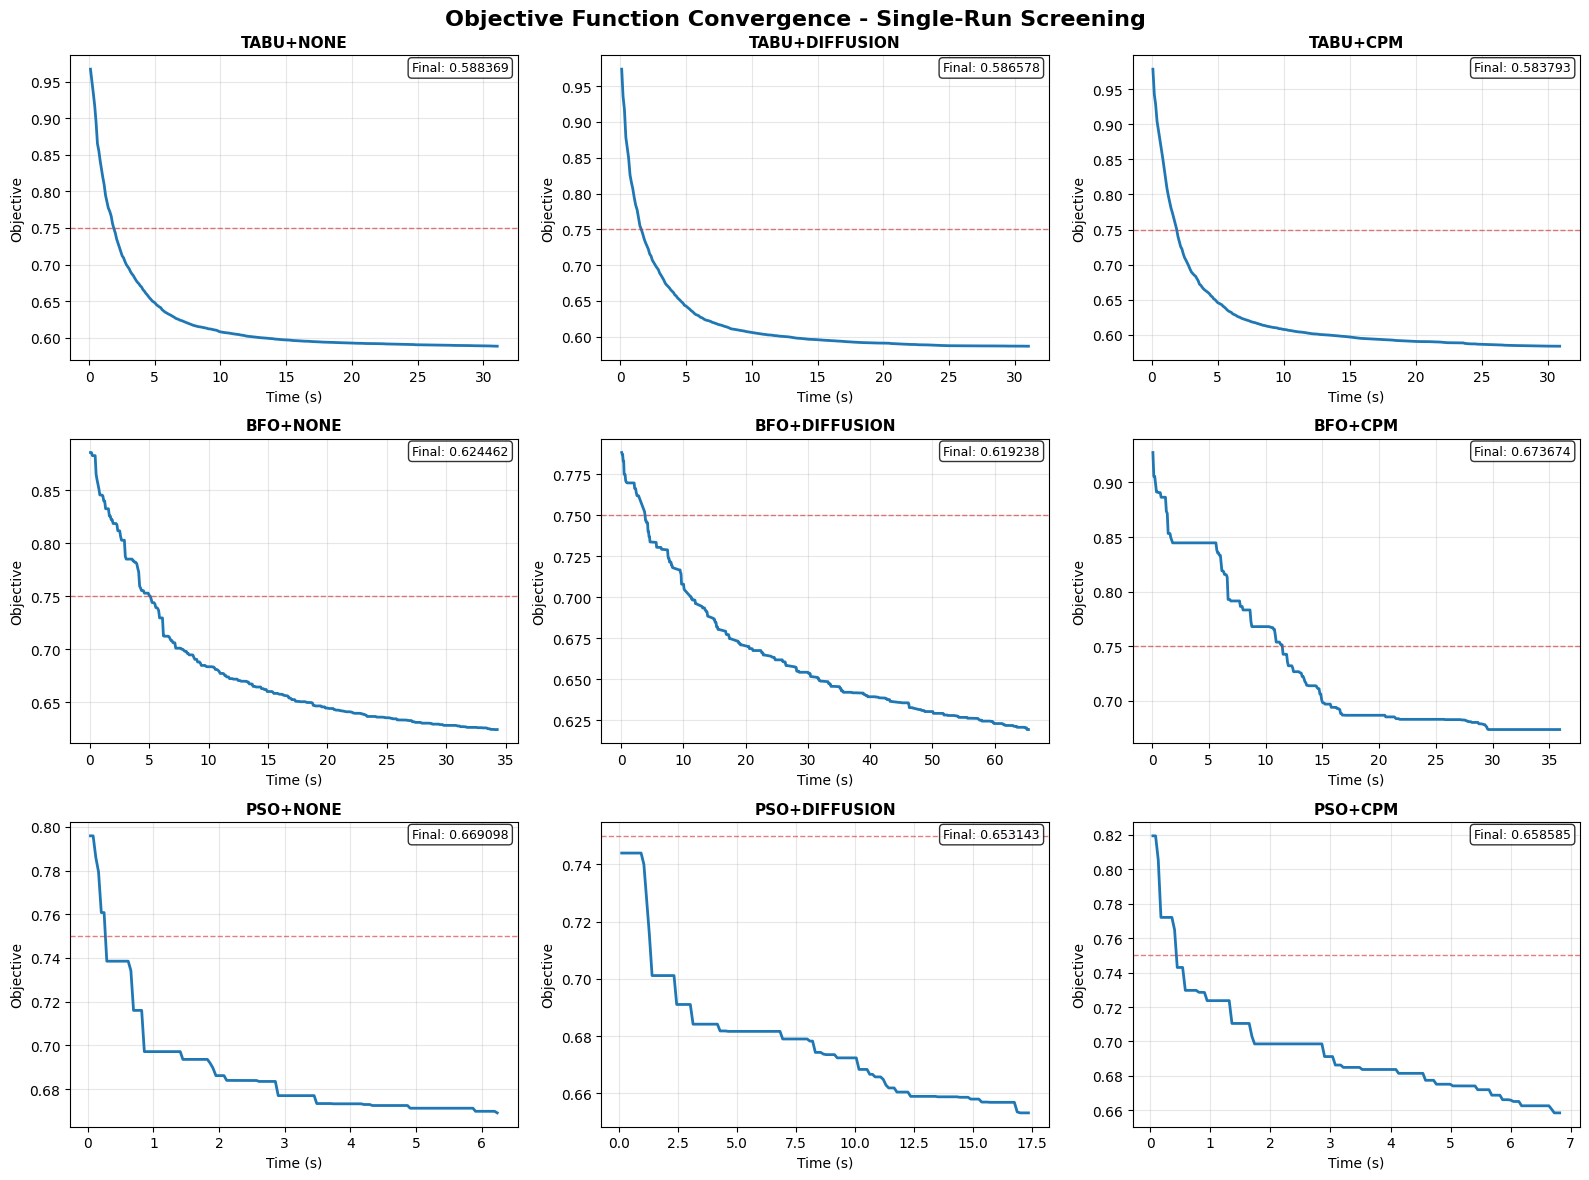

=== SCREENING RANKING ===


,model,final_obj,best_obj,time_to_target_s,runtime_s,energy,latency,improvement_vs_rr_pct,rank_objective,rank_ttt,rank_runtime
0,TABU+CPM,0.583793,0.583793,1.997635,30.901413,305.101584,3.240360,41.620666,1.0,6.0,4.0
1,TABU+DIFFUSION,0.586578,0.586578,1.609015,31.116671,304.907366,3.320201,41.342209,2.0,4.0,6.0
2,TABU+NONE,0.588369,0.588369,1.891720,31.046753,305.398365,3.347526,41.163058,3.0,5.0,5.0
3,BFO+DIFFUSION,0.619238,0.619238,3.838188,66.337053,311.442167,3.912665,38.076197,4.0,7.0,9.0
4,BFO+NONE,0.624462,0.624462,5.177927,34.271113,314.321531,3.935826,37.553840,5.0,8.0,7.0
5,PSO+DIFFUSION,0.653143,0.653143,0.235295,17.340311,321.858445,4.385913,34.685744,6.0,1.0,3.0
6,PSO+CPM,0.658585,0.658585,0.449691,6.817046,325.989282,4.365896,34.141530,7.0,3.0,2.0
7,PSO+NONE,0.669098,0.669098,0.289912,6.236118,321.976583,4.795347,33.090213,8.0,2.0,1.0
8,BFO+CPM,0.673674,0.673674,11.546837,35.975358,338.213814,4.280291,32.632625,9.0,9.0,8.0


In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Objective Function Convergence - Single-Run Screening", fontsize=16, fontweight="bold")

for ax, (global_opt, local_opt) in zip(axes.ravel(), EXPERIMENT_COMBINATIONS):
    history = RESULTS.get(global_opt, {}).get(local_opt)
    title = f"{global_opt.upper()}+{local_opt.upper()}"

    if history is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue

    times = np.array(history.get("time", []), dtype=float)
    objs = np.array(history.get("obj", []), dtype=float)
    if len(times) != len(objs):
        times = np.linspace(0, history.get("runtime", 1.0), len(objs))

    ax.plot(times, objs, linewidth=2, color="tab:blue")
    ax.axhline(TTT_THRESHOLD, color="tab:red", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Objective")
    ax.grid(True, alpha=0.3)
    ax.text(
        0.98,
        0.98,
        f"Final: {objs[-1]:.6f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
    )

plt.tight_layout()
plt.show()

print("=== SCREENING RANKING ===")
display(screening_ranked)


## Top-3 CDF Evaluation

CDF dijalankan hanya untuk tiga model dengan final objective terbaik dari single-run screening. Pendekatan ini membuat notebook tetap defensible untuk reviewer:

- semua model sudah dibandingkan pada tahap screening,
- CDF dipakai untuk menguji stabilitas kandidat terbaik,
- jumlah run dapat dinaikkan jika waktu komputasi tersedia.

Default saat ini adalah `50 runs` per model. Untuk final yang lebih kuat, nilai ini bisa dinaikkan ke 100 atau 300 setelah hasil awal sudah jelas.


In [ ]:
# ============================================================
# SECTION 18 - TOP-3 CDF SETUP
# ============================================================

runs = int(globals().get("runs", 10))  # Default 50; runner scripts can override this value.
CDF_MODELS = TOP_CDF_MODELS[:TOP_K_FOR_CDF]

scores = {}
energy_scores = {}
latency_scores = {}

MODEL_LOOKUP = {
    f"{global_opt.upper()}+{local_opt.upper()}": (global_opt, local_opt)
    for global_opt, local_opt in EXPERIMENT_COMBINATIONS
}


def run_global_optimizer(optimizer_name, system_model_instance, local_optimizer_name):
    local_opt_instance = build_local_optimizer(local_optimizer_name, topology)

    if optimizer_name == "tabu":
        return hybrid_tabu(system_model_instance, local_opt_instance)
    if optimizer_name == "bfo":
        return hybrid_bfo(system_model_instance, local_opt_instance)
    if optimizer_name == "pso":
        return hybrid_pso(system_model_instance, local_opt_instance)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def run_cdf_for_models(model_names, n_runs):
    for name in model_names:
        global_opt, local_opt = MODEL_LOOKUP[name]
        scores[name] = []
        energy_scores[name] = []
        latency_scores[name] = []

        print(f"--- Running CDF: {name} ({n_runs} runs) ---")
        for r in range(n_runs):
            print(f"Run {r + 1}/{n_runs}")
            _, history = run_global_optimizer(
                optimizer_name=global_opt,
                system_model_instance=system_model_instance,
                local_optimizer_name=local_opt,
            )

            scores[name].append(float(history["obj"][-1]))
            energy_scores[name].append(float(history["energy"][-1]))
            latency_scores[name].append(float(history["latency"][-1]))

    return scores, energy_scores, latency_scores

print("Models selected for CDF:", CDF_MODELS)
print("Runs per model:", runs)


Models selected for CDF: ['TABU+CPM', 'TABU+DIFFUSION', 'TABU+NONE']
Runs per model: 50


### Run CDF for Selected Top-3 Models

In [38]:
scores, energy_scores, latency_scores = run_cdf_for_models(CDF_MODELS, runs)

cdf_summary_rows = []
for name in CDF_MODELS:
    obj = np.array(scores[name], dtype=float)
    energy = np.array(energy_scores[name], dtype=float)
    latency = np.array(latency_scores[name], dtype=float)
    cdf_summary_rows.append({
        "model": name,
        "runs": len(obj),
        "objective_mean": float(np.mean(obj)),
        "objective_std": float(np.std(obj)),
        "objective_min": float(np.min(obj)),
        "objective_max": float(np.max(obj)),
        "energy_mean": float(np.mean(energy)),
        "latency_mean": float(np.mean(latency)),
    })

cdf_summary_df = pd.DataFrame(cdf_summary_rows).sort_values(
    ["objective_mean", "objective_std"],
    ascending=[True, True],
).reset_index(drop=True)

display(cdf_summary_df)


--- Running CDF: TABU+CPM (50 runs) ---
Run 1/50
Run 2/50
Run 3/50
Run 4/50
Run 5/50
Run 6/50
Run 7/50
Run 8/50
Run 9/50
Run 10/50
Run 11/50
Run 12/50
Run 13/50
Run 14/50
Run 15/50
Run 16/50
Run 17/50
Run 18/50
Run 19/50
Run 20/50
Run 21/50
Run 22/50
Run 23/50
Run 24/50
Run 25/50
Run 26/50
Run 27/50
Run 28/50
Run 29/50
Run 30/50
Run 31/50
Run 32/50
Run 33/50
Run 34/50
Run 35/50
Run 36/50
Run 37/50
Run 38/50
Run 39/50
Run 40/50
Run 41/50
Run 42/50
Run 43/50
Run 44/50
Run 45/50
Run 46/50
Run 47/50
Run 48/50
Run 49/50
Run 50/50
--- Running CDF: TABU+DIFFUSION (50 runs) ---
Run 1/50
Run 2/50
Run 3/50
Run 4/50
Run 5/50
Run 6/50
Run 7/50
Run 8/50
Run 9/50
Run 10/50
Run 11/50
Run 12/50
Run 13/50
Run 14/50
Run 15/50
Run 16/50
Run 17/50
Run 18/50
Run 19/50
Run 20/50
Run 21/50
Run 22/50
Run 23/50
Run 24/50
Run 25/50
Run 26/50
Run 27/50
Run 28/50
Run 29/50
Run 30/50
Run 31/50
Run 32/50
Run 33/50
Run 34/50
Run 35/50
Run 36/50
Run 37/50
Run 38/50
Run 39/50
Run 40/50
Run 41/50
Run 42/50
Run 43/50
Ru

,model,runs,objective_mean,objective_std,objective_min,objective_max,energy_mean,latency_mean
0,TABU+CPM,50,0.653740,0.001117,0.650785,0.656202,304.517421,3.376252
1,TABU+NONE,50,0.653817,0.001007,0.651426,0.655601,304.498902,3.379829
2,TABU+DIFFUSION,50,0.654083,0.001077,0.651180,0.657026,304.492180,3.388874


## Visualisasi CDF Top-3

Bagian ini memplot CDF untuk model yang masuk `CDF_MODELS`. Plot individual membantu membaca setiap distribusi secara terpisah, sedangkan plot gabungan menunjukkan model mana yang kurvanya paling bergeser ke kiri.


In [22]:
import numpy as np


def compute_cdf(data):
    sorted_data = np.sort(np.array(data, dtype=float))
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


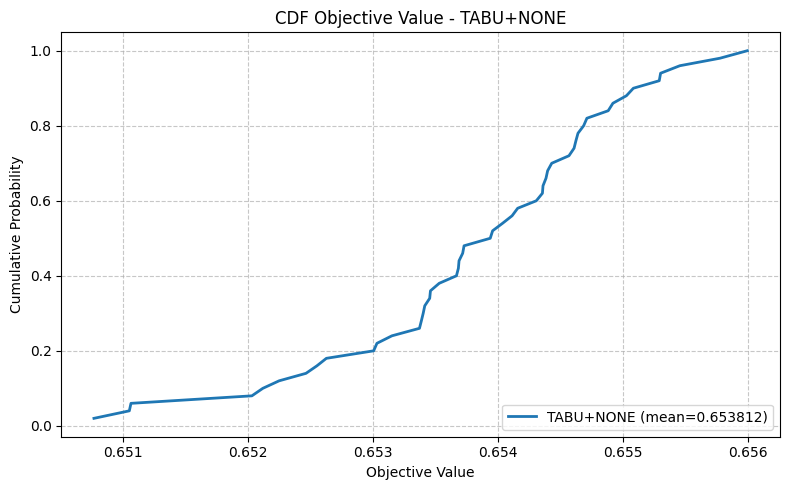

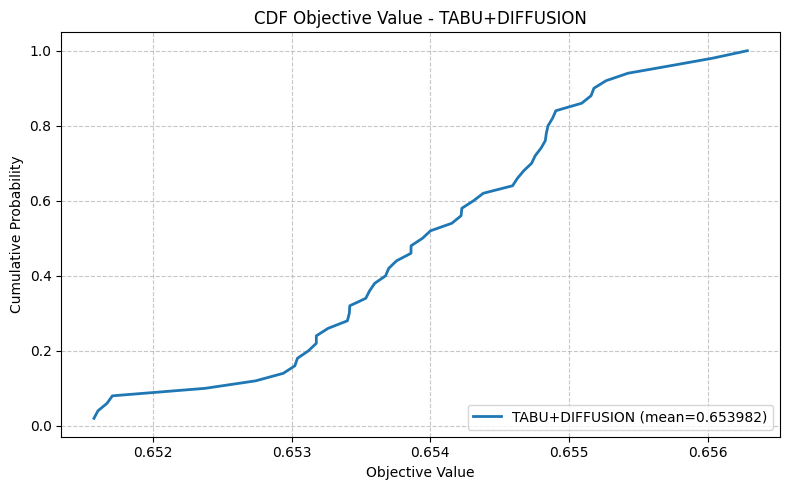

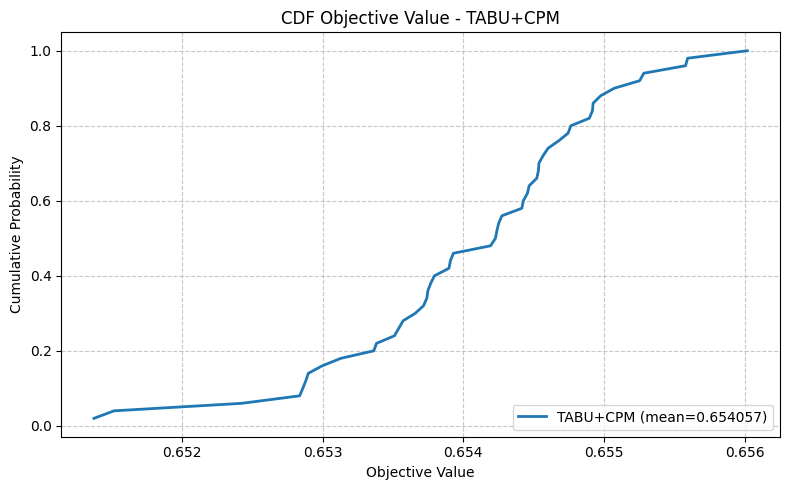

In [23]:
import matplotlib.pyplot as plt

for name in sorted(scores.keys(), key=lambda n: np.mean(scores[n])):
    x_cdf, y_cdf = compute_cdf(scores[name])
    mean_value = np.mean(scores[name])

    plt.figure(figsize=(8, 5))
    plt.plot(x_cdf, y_cdf, linewidth=2, color="tab:blue", label=f"{name} (mean={mean_value:.6f})")
    plt.title(f"CDF Objective Value - {name}")
    plt.xlabel("Objective Value")
    plt.ylabel("Cumulative Probability")
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


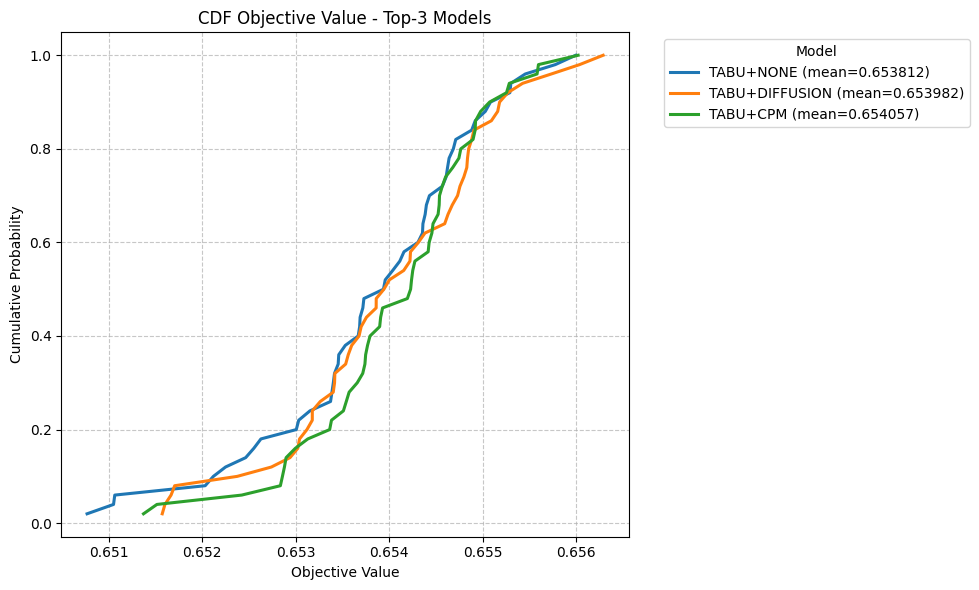

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name in sorted(scores.keys(), key=lambda n: np.mean(scores[n])):
    x_cdf, y_cdf = compute_cdf(scores[name])
    plt.plot(x_cdf, y_cdf, linewidth=2.2, label=f"{name} (mean={np.mean(scores[name]):.6f})")

plt.title("CDF Objective Value - Top-3 Models")
plt.xlabel("Objective Value")
plt.ylabel("Cumulative Probability")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### CDF Interpretation

Kurva CDF yang lebih bergeser ke kiri menunjukkan model lebih sering menghasilkan objective value yang rendah. Selain posisi kurva, lihat juga `objective_std`: nilai std yang lebih kecil menunjukkan performa lebih stabil antar run.


### Energy-Latency Trade-off

Objective value harus dibaca bersama energy dan latency. Model dengan objective rendah tetapi energy/latency timpang perlu dibahas sebagai trade-off, bukan langsung dianggap unggul mutlak.


## Ringkasan Statistik CDF

Tabel `cdf_summary_df` merangkum mean, standard deviation, nilai minimum, nilai maksimum, rata-rata energy, dan rata-rata latency dari top 3 model. Gunakan tabel ini bersama grafik CDF untuk memilih kandidat akhir dari fase simulasi.


In [25]:
display(cdf_summary_df)


,model,runs,objective_mean,objective_std,objective_min,objective_max,energy_mean,latency_mean
0,TABU+NONE,50,0.653812,0.001166,0.650770,0.655993,304.487481,3.380360
1,TABU+DIFFUSION,50,0.653982,0.001105,0.651573,0.656286,304.505534,3.384792
2,TABU+CPM,50,0.654057,0.000952,0.651373,0.656019,304.497901,3.387683


## Ringkasan Analisis untuk Reviewer

Setelah notebook dijalankan, gunakan bagian ini untuk membaca hasil:

1. **Konvergensi**: model yang kurvanya turun cepat dan stabil lebih baik.
2. **Time-to-target**: model yang lebih cepat mencapai objective <= 0.75 lebih efisien secara proses pencarian.
3. **Runtime**: model dengan runtime terlalu tinggi perlu dibandingkan dengan manfaat objective yang diperoleh.
4. **CDF top 3**: model terbaik adalah yang rata-rata objective-nya rendah dan variasinya kecil.
5. **Energy-latency trade-off**: objective rendah perlu dicek apakah berasal dari perbaikan energy, latency, atau keduanya.


## Tuning Applied for Tabu-Diffusion

Tuning dari catatan rekomendasi sudah diterapkan pada cell yang benar-benar dieksekusi:

```text
TABU_MAX_ITER = 300
TABU_TENURE = 30
TABU_CANDIDATE_MOVES = 100
Diffusion gamma = 0.08
Diffusion max_steps = 1
Diffusion trigger = no_improve_counter >= TABU_STAGNATION_TRIGGER
```

Tujuan tuning ini adalah membuat Diffusion lebih sering membantu Tabu keluar dari stagnasi, sambil tetap menjaga runtime dalam batas yang masuk akal.


## Checklist Sebelum Run Manual

Jalankan notebook dari atas ke bawah.

Pastikan hal berikut sebelum menjalankan CDF:

- Cell baseline sudah menghasilkan objective Round-Robin = 1.0.
- Cell single-run screening sudah menghasilkan `screening_ranked` dan `TOP_CDF_MODELS`.
- Default CDF adalah `runs = 50`; naikkan hanya jika waktu komputasi cukup.
- CDF hanya berjalan untuk top 3 model hasil screening.
- Setelah run selesai, baca `cdf_summary_df` dan grafik CDF top 3.

Untuk penulisan skripsi, gunakan hasil screening sebagai bukti semua model sudah dibandingkan, lalu gunakan CDF top 3 sebagai bukti stabilitas kandidat terbaik.
